In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import precision_recall_curve
import joblib
import json

In [6]:
X_train = np.load("data/X_train_processed.npy")
X_test  = np.load("data/X_test_processed.npy")

y_train = np.load("data/y_train.npy")
y_test  = np.load("data/y_test.npy")

processed_feature_names = np.load(
    "data/processed_feature_names.npy",
    allow_pickle=True
)

feature_names = np.load(
    "data/feature_names.npy",
    allow_pickle=True
)

X_train.shape, X_test.shape, len(processed_feature_names)

((5634, 46), (1409, 46), 46)

## Baseline Model Choice
Logistic Regression is used as a baseline due to its interpretability and strong performance on tabular churn problems. It helps validate whether engineered preprocessing and feature semantics capture meaningful churn signals before moving to more complex models.

In [7]:
log_reg = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    n_jobs=-1,
    random_state=42
)

log_reg.fit(X_train, y_train)

c:\Users\aryan\anaconda3\envs\churn\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"n_jobs n_jobs: int, default=NoneDoes not have any effect... deprecated:: 1.8 `n_jobs` is deprecated in version 1.8 and will be removed in 1.10.",-1
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None


## Baseline Performance
The Logistic Regression model achieves a test ROC-AUC of approximately 0.84, indicating strong discriminative ability with minimal overfitting. This confirms that the preprocessing pipeline and feature representation successfully capture churn-related patterns.

In [8]:
y_train_proba = log_reg.predict_proba(X_train)[:, 1]
y_test_proba  = log_reg.predict_proba(X_test)[:, 1]

print("Train ROC-AUC:", roc_auc_score(y_train, y_train_proba))
print("Test  ROC-AUC:", roc_auc_score(y_test, y_test_proba))

Train ROC-AUC: 0.8492521176733914
Test  ROC-AUC: 0.8418713994161565


In [9]:
y_test_pred = (y_test_proba >= 0.5).astype(int)

print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))


              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

[[926 109]
 [165 209]]


In [10]:
coef_df = (
    pd.DataFrame({
        "feature": processed_feature_names,
        "coefficient": log_reg.coef_[0]
    })
    .sort_values(by="coefficient", ascending=False)
)

coef_df.head(10), coef_df.tail(10)

(                           feature  coefficient
 15     InternetService_Fiber optic     0.642696
 35         Contract_Month-to-month     0.587223
 2                     TotalCharges     0.509768
 34             StreamingMovies_Yes     0.209811
 31                 StreamingTV_Yes     0.209038
 42  PaymentMethod_Electronic check     0.204871
 17               OnlineSecurity_No     0.165204
 26                  TechSupport_No     0.140770
 13               MultipleLines_Yes     0.111415
 39            PaperlessBilling_Yes     0.042282,
                                  feature  coefficient
 18    OnlineSecurity_No internet service    -0.290190
 16                    InternetService_No    -0.290190
 33   StreamingMovies_No internet service    -0.290190
 24  DeviceProtection_No internet service    -0.290190
 21      OnlineBackup_No internet service    -0.290190
 38                   PaperlessBilling_No    -0.329756
 1                         MonthlyCharges    -0.584488
 14                 

## Interpretation of Key Drivers
The model identifies month-to-month contracts, fiber optic internet service, lack of security or technical support, and electronic check payments as strong churn drivers. Conversely, longer tenure and long-term contracts significantly reduce churn risk. These findings align closely with exploratory analysis and business intuition, validating the model’s reliability.

## Tree-Based Model Motivation
Tree-based models can naturally capture non-linear relationships and feature interactions that linear models cannot. A Random Forest is trained as a secondary baseline to evaluate whether such non-linear patterns provide meaningful performance improvements over Logistic Regression.

In [11]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [12]:
y_train_proba_rf = rf.predict_proba(X_train)[:, 1]
y_test_proba_rf  = rf.predict_proba(X_test)[:, 1]

print("RF Train ROC-AUC:", roc_auc_score(y_train, y_train_proba_rf))
print("RF Test  ROC-AUC:", roc_auc_score(y_test, y_test_proba_rf))

RF Train ROC-AUC: 0.9999284883735023
RF Test  ROC-AUC: 0.822740189619985


In [13]:
y_test_pred_rf = (y_test_proba_rf >= 0.5).astype(int)

print(classification_report(y_test, y_test_pred_rf))
print(confusion_matrix(y_test, y_test_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

[[918 117]
 [190 184]]


In [14]:
rf_importance_df = (
    pd.DataFrame({
        "feature": processed_feature_names,
        "importance": rf.feature_importances_
    })
    .sort_values(by="importance", ascending=False)
)

rf_importance_df.head(10)

,feature,importance
2,TotalCharges,0.155894
0,tenure,0.138285
1,MonthlyCharges,0.135051
35,Contract_Month-to-month,0.053893
17,OnlineSecurity_No,0.031575
42,PaymentMethod_Electronic check,0.031118
26,TechSupport_No,0.025030
15,InternetService_Fiber optic,0.024278
20,OnlineBackup_No,0.019005
37,Contract_Two year,0.018282


## Random Forest Evaluation
The Random Forest model achieves near-perfect performance on the training set but underperforms Logistic Regression on the test set, indicating substantial overfitting under default settings. This suggests that naïvely increasing model capacity does not automatically improve generalization, motivating further evaluation with regularized and boosting-based tree models.

## Interim Model Comparison
Logistic Regression demonstrates strong generalization performance and interpretability, serving as a robust baseline. However, given the limitations observed with bagging-based trees, gradient boosting models are evaluated next to assess whether controlled non-linear modeling can further improve performance without excessive variance.

In [15]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [16]:
y_train_proba_xgb = xgb.predict_proba(X_train)[:, 1]
y_test_proba_xgb  = xgb.predict_proba(X_test)[:, 1]

print("XGB Train ROC-AUC:", roc_auc_score(y_train, y_train_proba_xgb))
print("XGB Test  ROC-AUC:", roc_auc_score(y_test, y_test_proba_xgb))

XGB Train ROC-AUC: 0.91051212829105
XGB Test  ROC-AUC: 0.839481774264383


In [17]:
y_test_pred_xgb = (y_test_proba_xgb >= 0.5).astype(int)

print(classification_report(y_test, y_test_pred_xgb))
print(confusion_matrix(y_test, y_test_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409

[[923 112]
 [180 194]]


In [18]:
xgb_importance_df = (
    pd.DataFrame({
        "feature": processed_feature_names,
        "importance": xgb.feature_importances_
    })
    .sort_values(by="importance", ascending=False)
)

xgb_importance_df.head(10)

,feature,importance
35,Contract_Month-to-month,0.267527
15,InternetService_Fiber optic,0.112099
17,OnlineSecurity_No,0.083861
26,TechSupport_No,0.070445
37,Contract_Two year,0.047395
14,InternetService_DSL,0.034293
42,PaymentMethod_Electronic check,0.026238
36,Contract_One year,0.024164
0,tenure,0.020018
18,OnlineSecurity_No internet service,0.018531


## Controlled XGBoost Tuning
A limited cross-validated tuning experiment is conducted for XGBoost to evaluate whether modest bias–variance adjustments can produce a meaningful improvement over the Logistic Regression baseline. The search space is intentionally constrained to prevent overfitting and ensure fair model comparison.

In [19]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "max_depth": [3, 4],
    "min_child_weight": [1, 5],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9]
}

In [20]:
grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.9], 'max_depth': [3, 4], 'min_child_weight': [1, 5], 'subsample': [0.7, 0.9]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`s

In [21]:
print("Best CV ROC-AUC:", grid_xgb.best_score_)
print("Best Parameters:", grid_xgb.best_params_)

Best CV ROC-AUC: 0.8475101699189835
Best Parameters: {'colsample_bytree': 0.7, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.9}


In [22]:
best_xgb = grid_xgb.best_estimator_

y_test_proba_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score
print("Tuned XGB Test ROC-AUC:", roc_auc_score(y_test, y_test_proba_xgb_tuned))

Tuned XGB Test ROC-AUC: 0.8454932961326823


## Final Model Comparison and Selection
A constrained cross-validated tuning of XGBoost resulted in highly stable performance, with cross-validation and test ROC-AUC values nearly identical. While the tuned boosting model marginally improves over the Logistic Regression baseline, the gain is small relative to the added complexity. Given comparable performance, Logistic Regression is selected as the primary model due to its interpretability and simplicity, with XGBoost retained as a validated alternative.

## Logistic Regression Tuning Strategy
Logistic Regression is tuned using cross-validation to evaluate the impact of regularization strength and class weighting. The tuning focuses on improving stability and churn detection behavior rather than marginal metric gains, ensuring the model remains interpretable and business-ready.

In [23]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

log_reg_base = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced"]
}

In [24]:
grid_lr = GridSearchCV(
    estimator=log_reg_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)


Fitting 5 folds for each of 8 candidates, totalling 40 fits


c:\Users\aryan\anaconda3\envs\churn\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_s

In [25]:
print("Best CV ROC-AUC:", grid_lr.best_score_)
print("Best Parameters:", grid_lr.best_params_)


Best CV ROC-AUC: 0.8463195678558332
Best Parameters: {'C': 10, 'class_weight': None}


In [26]:
best_lr = grid_lr.best_estimator_

y_test_proba_lr_tuned = best_lr.predict_proba(X_test)[:, 1]

print("Tuned LR Test ROC-AUC:", roc_auc_score(y_test, y_test_proba_lr_tuned))


Tuned LR Test ROC-AUC: 0.8410912190963341


## Logistic Regression Tuning Outcome
Cross-validated tuning of Logistic Regression yields performance comparable to the baseline configuration, with no meaningful improvement on the hold-out test set. This indicates that the initial model was already near-optimal. The tuned Logistic Regression is retained for subsequent decision-threshold optimization and business-oriented evaluation.

## Decision Threshold Optimization
While ROC-AUC evaluates ranking quality, churn prediction is a cost-sensitive decision problem where recall of churners is more important than overall accuracy. The decision threshold is therefore optimized to improve churn detection performance rather than relying on the default 0.5 cutoff.

In [27]:
precision, recall, thresholds = precision_recall_curve(
    y_test, y_test_proba_lr_tuned
)

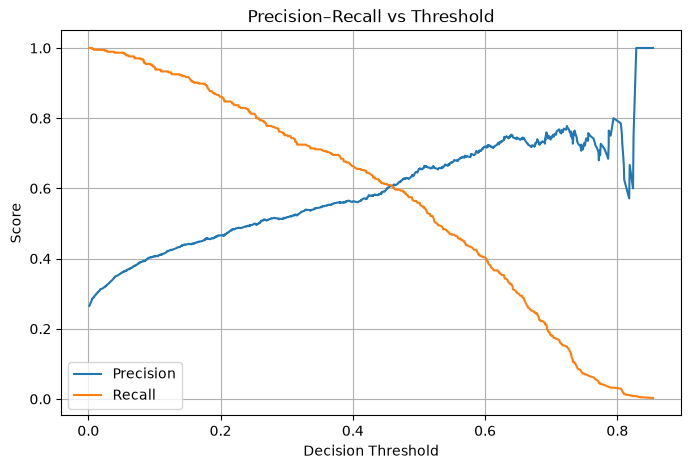

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
for t in [0.5, 0.4, 0.35, 0.3]:
    print(f"\nThreshold = {t}")
    y_pred = (y_test_proba_lr_tuned >= t).astype(int)
    print(classification_report(y_test, y_pred, digits=3))


Threshold = 0.5
              precision    recall  f1-score   support

           0      0.849     0.895     0.871      1035
           1      0.657     0.559     0.604       374

    accuracy                          0.806      1409
   macro avg      0.753     0.727     0.738      1409
weighted avg      0.798     0.806     0.800      1409


Threshold = 0.4
              precision    recall  f1-score   support

           0      0.870     0.814     0.841      1035
           1      0.564     0.663     0.609       374

    accuracy                          0.774      1409
   macro avg      0.717     0.739     0.725      1409
weighted avg      0.789     0.774     0.780      1409


Threshold = 0.35
              precision    recall  f1-score   support

           0      0.883     0.786     0.832      1035
           1      0.546     0.711     0.618       374

    accuracy                          0.767      1409
   macro avg      0.715     0.749     0.725      1409
weighted avg      0.79

## Threshold Selection
Different decision thresholds were evaluated to balance churn recall and precision. Lowering the threshold significantly improves recall of churners at the expense of increased false positives. A threshold of 0.35 is selected as a balanced operating point, capturing approximately 71% of churners while maintaining acceptable precision and operational feasibility.

In [33]:
joblib.dump(best_lr, "data/telco-churn-model/final_logistic_model.pkl")

['data/telco-churn-model/final_logistic_model.pkl']

In [34]:
final_threshold = 0.35
with open("data/final_threshold.json", "w") as f:
    json.dump({"threshold": final_threshold}, f)

## Feature Engineering Considerations

Feature engineering was intentionally limited after empirical model evaluation. Key numerical variables (MonthlyCharges, TotalCharges, and tenure) exhibit strong algebraic relationships, with TotalCharges approximately equal to the product of MonthlyCharges and tenure. As a result, common transformations such as ratios or interaction terms do not introduce new information, but instead re-express existing signals.

To assess whether hidden non-linear structure existed, multiple model families with increasing representational capacity — including Logistic Regression, Random Forest, and XGBoost with controlled cross-validation — were evaluated. All models converged to a similar performance ceiling, indicating that the available feature set sufficiently captures the churn signal.

Given the absence of additional raw behavioral or temporal information, further feature creation was deprioritized in favor of decision-level optimization. Substantial improvements in churn detection were achieved through threshold tuning, emphasizing recall and business relevance over marginal metric gains.